# Clade C2 results

## Imports etc

In [60]:
# Load the correct grid parameters:
import importlib
!cp grid_params_clade_C2.py grid_params.py


In [61]:
# Import elfi_model.py
 
import elfi_model
importlib.reload(elfi_model)
from elfi_model import *

import elfi_vis
importlib.reload(elfi_vis)
from elfi_vis import *

Loading BSI_functions.py
Grid parameters:
Clade: C2
Number of weeks to simulate: 728
Population size: 1000000
Year
2004     0.000390
2005     0.000395
2006     0.000421
2007     8.428780
2008     7.024155
2009     8.686990
2010     3.070367
2011     5.760377
2012    10.741828
2013    21.234113
2014    13.656576
2015    25.312731
2016    15.188393
2017    16.567411
Name: C2, dtype: float64
Model imported


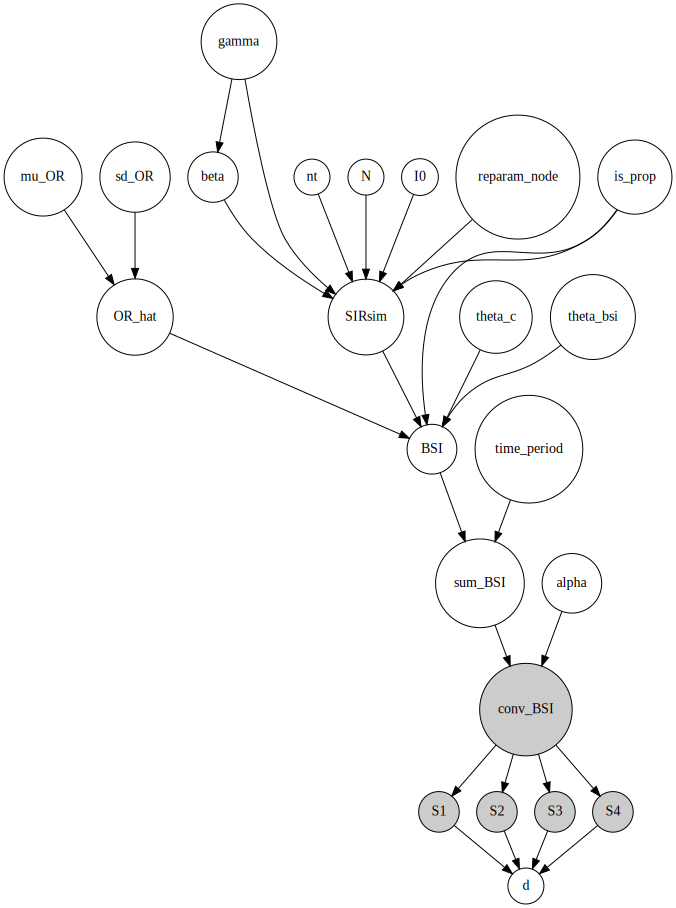

In [62]:
elfi.draw(m)

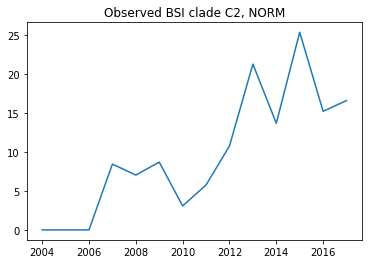

In [63]:
# Plot the observed data

plt.plot(bsi_obs_data)
plt.title(f"Observed BSI clade {clade}, {obs_data}")
plt.show()


## Visualizing the prior

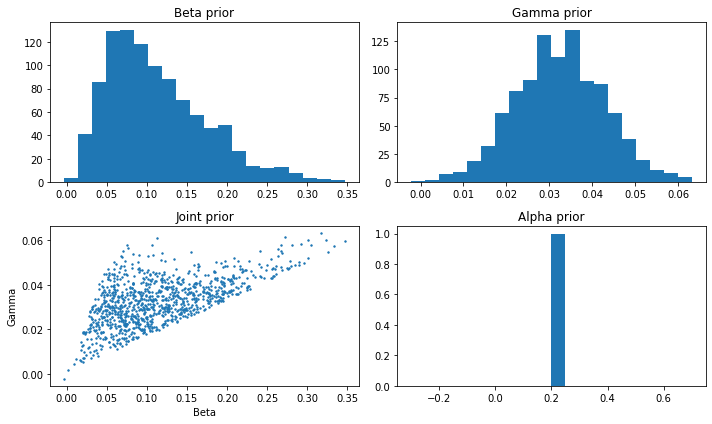

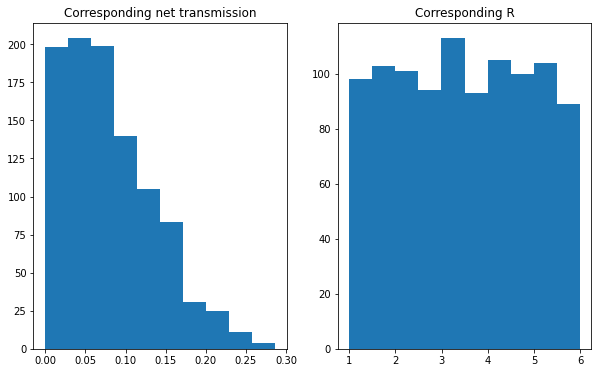

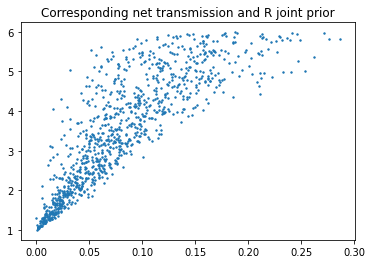

In [64]:
# Plot the priors

def plot_priors_elfi():
    prior_sample =  m.generate(1000, outputs = ["gamma", "beta"])
    g = prior_sample["gamma"]
    b = prior_sample["beta"]
    a_sample = alpha.generate(1000)


    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(b, bins=20)
    axs[0, 0].set_title('Beta prior')
    axs[0, 1].hist(g, bins=20)
    axs[0, 1].set_title('Gamma prior')

    axs[1, 0].scatter(b,g, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel('Beta')
    axs[1, 0].set_ylabel('Gamma')

    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    plt.show()


    fig, axs = plt.subplots(1, 2, figsize=(10, 6))
    nt_sample = b - g
    R_sample = b/g
    axs[0].hist(nt_sample)
    axs[0].set_title("Corresponding net transmission")

    axs[1].hist(R_sample)
    axs[1].set_title("Corresponding R")
    plt.show()


    plt.scatter(nt_sample, R_sample, s=2)
    plt.title("Corresponding net transmission and R joint prior")
    plt.show()
    
if not reparam:    
    plot_priors_elfi()
else:
    net_sample = net_transmission.generate(1000)
    R_sample = R.generate(1000)
    a_sample = alpha.generate(1000)

    #print(R_sample.shape)
    #print(net_sample.shape)
    
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(net_sample, bins=20)
    axs[0, 0].set_title('Net transmission prior')
    axs[0, 1].hist(R_sample, bins=20)
    axs[0, 1].set_title('R prior')
    
    axs[1, 0].scatter(net_sample, R_sample, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel('Net transmission')
    axs[1, 0].set_ylabel('R')
    
    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    filename = "nt_R_beta_priors.pdf"
    plt.savefig(filename, format="pdf", bbox_inches="tight")
    plt.show()
    
    or_sample = OR_hat.generate(1000)
    plt.hist(or_sample)
    plt.title("OR prior")
    plt.show()
    

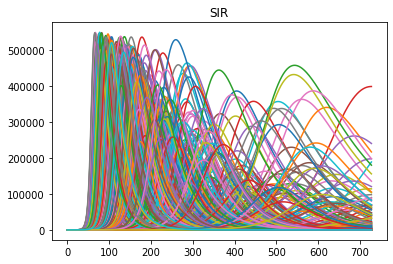

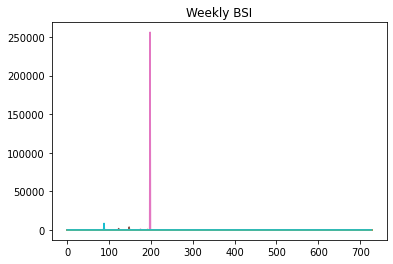

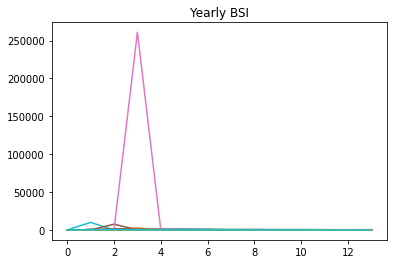

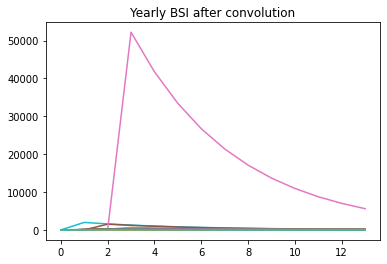

In [65]:
# Simulations from the prior:
sim_dict = m.generate(batch_size= 500, outputs = ["SIRsim", "BSI", "conv_BSI", "sum_BSI"])


plt.plot(sim_dict["SIRsim"][1].T)
plt.title("SIR")
plt.show()

plt.plot(sim_dict["BSI"].T)
plt.title("Weekly BSI")
plt.show()

plt.plot(sim_dict["sum_BSI"].T)
plt.title("Yearly BSI")
plt.show()

plt.plot(sim_dict["conv_BSI"].T)
plt.title("Yearly BSI after convolution")
plt.show()

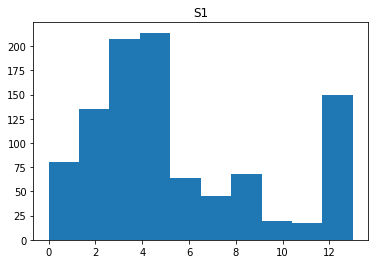

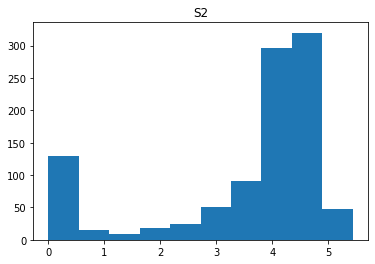

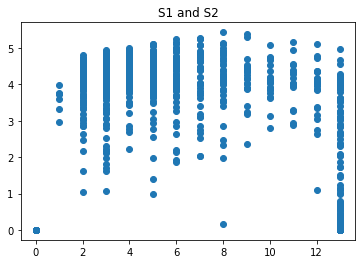

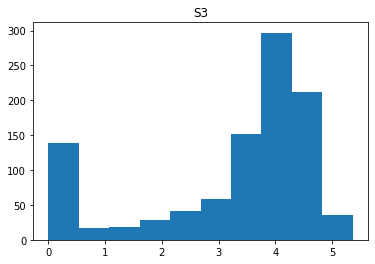

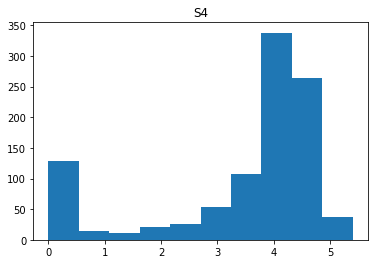

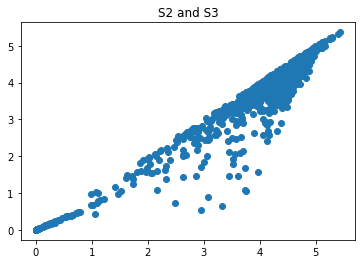

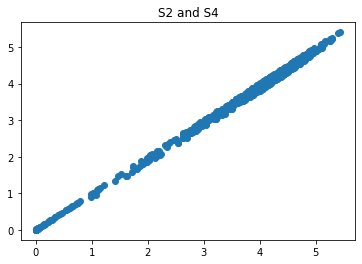

In [66]:
# Visualize summaries:
ssample = m.generate(1000, outputs = ["S1", "S2", "S3", "S4"])

plt.hist(ssample["S1"])
plt.title("S1")
plt.show()

plt.hist(ssample["S2"])
plt.title("S2")
plt.show()

plt.scatter(ssample["S1"], ssample["S2"])
plt.title("S1 and S2")
plt.show()

plt.hist(ssample["S3"])
plt.title("S3")
plt.show()
plt.hist(ssample["S4"])
plt.title("S4")
plt.show()

# Summaries S3 and S4 (next and previous BSI from BSI_max) have an almost identical distribution to that of BSI_max 

plt.scatter(ssample["S2"], ssample["S3"])
plt.title("S2 and S3")
plt.show()
plt.scatter(ssample["S2"], ssample["S4"]) # Especially this. BSI_max_next
plt.title("S2 and S4")
plt.show()


## Rejection sampling

In [67]:
rej = elfi.Rejection(d, batch_size=100)
%time result = rej.sample(1000, quantile = 0.01)

Progress [==================================================] 100.0% Complete
CPU times: user 1min 17s, sys: 1.71 s, total: 1min 18s
Wall time: 1min 17s


In [68]:
#rej = elfi.SMC(d, batch_size=100)
#%time result = rej.sample(1000, thresholds = [1e12, 10000, 1000]) # Problem: lack of logpdf for custom beta prior :)

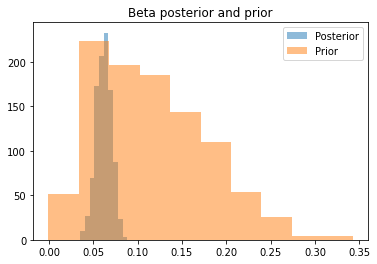

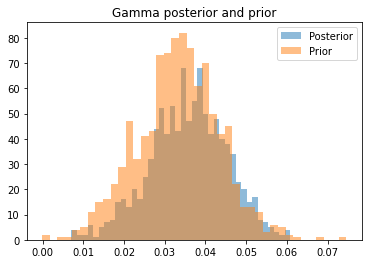

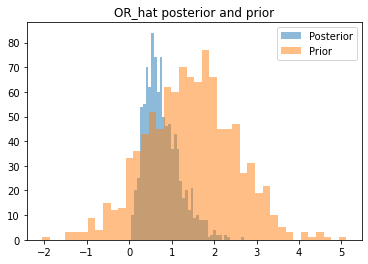

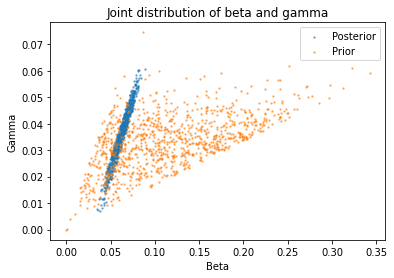

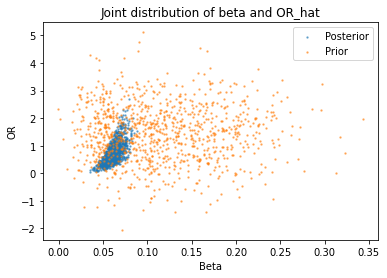

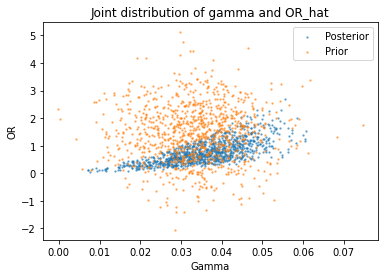

In [69]:
# Prior and posterior in the same figure

if not reparam:
    sample = m.generate(1000, ['beta', 'gamma', 'OR_hat'])

    # Beta
    plt.hist(result.samples['beta'], alpha = 0.5, label = "Posterior")
    plt.hist(sample['beta'], alpha = 0.5, label = "Prior")
    plt.title("Beta posterior and prior")
    plt.legend(loc = "upper right")
    plt.show()

    # Gamma
    plt.hist(result.samples['gamma'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
    plt.hist(sample['gamma'], alpha = 0.5, label = "Prior", bins = 40)
    plt.title("Gamma posterior and prior")
    plt.legend(loc = "upper right")
    plt.show()

    # OR_hat
    
    plt.hist(result.samples['OR_hat'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
    plt.hist(sample['OR_hat'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
    plt.title("OR_hat posterior and prior")
    plt.legend(loc = "upper right")
    plt.show()

    # Joint prior: beta, gamma
    plt.scatter(result.samples['beta'], result.samples['gamma'], alpha = 0.5, s = 2, label = "Posterior")
    plt.scatter(sample['beta'], sample['gamma'], alpha = 0.5, s= 2, label = "Prior")
    plt.title("Joint distribution of beta and gamma")
    plt.xlabel("Beta")
    plt.ylabel("Gamma")
    plt.legend(loc = "upper right")
    plt.show()
    
    # Joint prior: beta, OR
    
    plt.scatter(result.samples['beta'], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
    plt.scatter(sample['beta'], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
    plt.title("Joint distribution of beta and OR_hat")
    plt.xlabel("Beta")
    plt.ylabel("OR")
    plt.legend(loc = "upper right")
    plt.show()
    
    
    # Joint prior: gamma, OR
    
    plt.scatter(result.samples['gamma'], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
    plt.scatter(sample['gamma'], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
    plt.title("Joint distribution of gamma and OR_hat")
    plt.xlabel("Gamma")
    plt.ylabel("OR")
    plt.legend(loc = "upper right")
    plt.show()

array([[<AxesSubplot: ylabel='OR_hat'>, <AxesSubplot: >, <AxesSubplot: >],
       [<AxesSubplot: ylabel='beta'>, <AxesSubplot: >, <AxesSubplot: >],
       [<AxesSubplot: xlabel='OR_hat', ylabel='gamma'>,
        <AxesSubplot: xlabel='beta'>, <AxesSubplot: xlabel='gamma'>]],
      dtype=object)

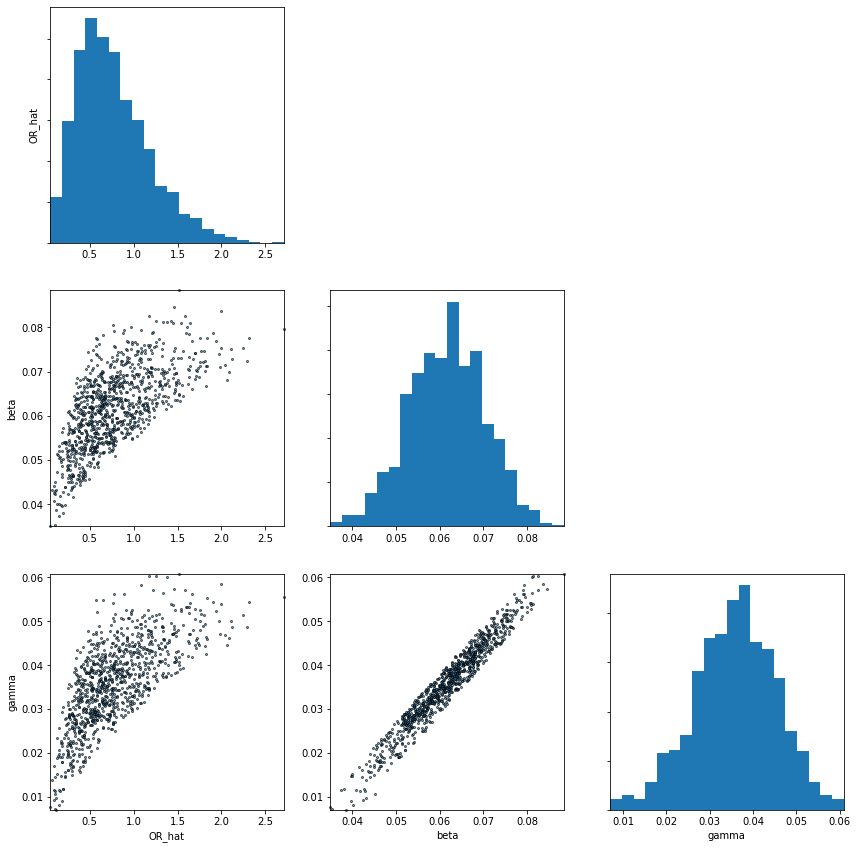

In [70]:
result.plot_pairs()

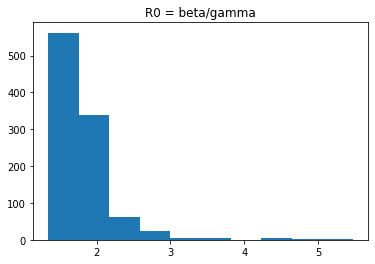

Mean of R: 1.810365366617607


In [71]:
# Plotting R0

R = result.samples['beta']/result.samples['gamma']

plt.hist(R)
plt.title("R0 = beta/gamma")
plt.show()

print(f"Mean of R: {R.mean()}")

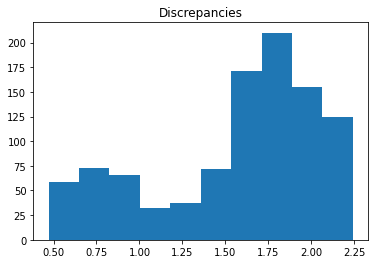

In [72]:
plt.hist(result.discrepancies)
plt.title("Discrepancies")
plt.show()

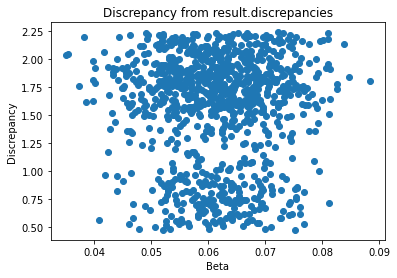

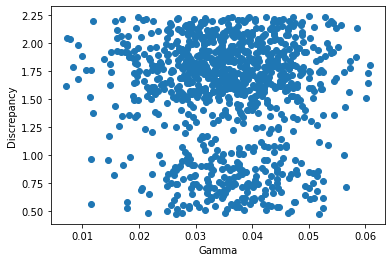

In [73]:
plt.scatter(result.samples['beta'], result.discrepancies)
plt.title("Discrepancy from result.discrepancies")
plt.xlabel("Beta")
plt.ylabel("Discrepancy")
plt.show()

plt.scatter(result.samples['gamma'], result.discrepancies)
plt.xlabel("Gamma")
plt.ylabel("Discrepancy")
plt.show()

In [74]:
def get_ppc(ci = 95):
    # Get posterior predictive check: plot a simulated mean and credible intervals on top of the observed data.
    
    par1_ci = np.percentile(result.samples['beta'], [(100-ci)/2, 100 - (100-ci)/2])
    par2_ci = np.percentile(result.samples['gamma'], [(100-ci)/2, 100 - (100-ci)/2])
    or_hat_ci = np.percentile(result.samples['OR_hat'], [(100-ci)/2, 100 - (100-ci)/2])
    
    par1_mean = result.samples['beta'].mean()
    par2_mean = result.samples['gamma'].mean()
    or_mean = result.samples['OR_hat'].mean()
    
    lower_curve = SIR_and_BSI_simulator(par1 = par1_ci[0],\
                                            par2 = par2_ci[0],\
                                            nt = n_weeks, N = pop_size,\
                                            bsi_pars = bsi_pars,\
                                            is_prop = is_prop,\
                                            is_agg = is_agg,\
                                            time_period = time_period.generate(1),\
                                            reparam = reparam,\
                                            batch_size = 1,\
                                            random_state = None,\
                                            has_or_hat = True,
                                            manual_or_hat = or_mean)[0]
    
    upper_curve = SIR_and_BSI_simulator(par1 = par1_ci[1],\
                                            par2 = par2_ci[1],\
                                            nt = n_weeks, N = pop_size,\
                                            bsi_pars = bsi_pars,\
                                            is_prop = is_prop,\
                                            is_agg = is_agg,\
                                            time_period = time_period.generate(1),\
                                            reparam = reparam,\
                                            batch_size = 1,\
                                            random_state = None,\
                                            has_or_hat = True,
                                            manual_or_hat = or_mean)[0]
    
    mean_curve = SIR_and_BSI_simulator(par1 = par1_mean,\
                                            par2 = par2_mean,\
                                            nt = n_weeks, N = pop_size,\
                                            bsi_pars = bsi_pars,\
                                            is_prop = is_prop,\
                                            is_agg = is_agg,\
                                            time_period = time_period.generate(1),\
                                            reparam = reparam,\
                                            batch_size = 1,\
                                            random_state = None,\
                                            has_or_hat = True,
                                            manual_or_hat = or_mean)[0]
    

    plt.plot(upper_curve, label = f"{ci}% CIs", color = "grey")
    plt.plot(lower_curve, color = "grey")
    plt.plot(mean_curve, color = "blue")
    plt.plot(np.array(bsi_obs_data), color = "red")
    plt.title(f"PPC, {ci}%CI")
    plt.show()
    
    plt.plot(np.array(bsi_obs_data), color = "red")
    plt.show()
    
    # The randomness of OR impacts the heigth of the curves considerably. OR should be learned and the mean value used to visualize.
    # If I put the mean of OR for all credible intervals as parameter, I get a better curve.
    # But if I use the quantiles, it messes up the credible intervals in the figure. Why?
    

False
False
False


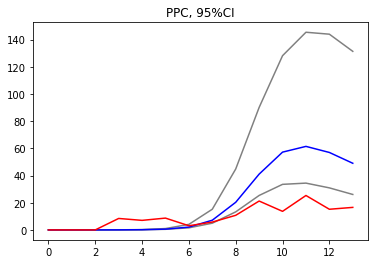

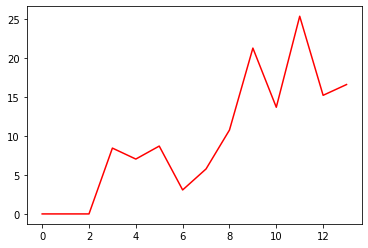

In [75]:
get_ppc()


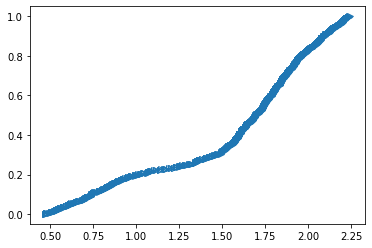

In [76]:
def ecdf(x):
    xs = np.sort(x)
    ys = np.arange(1, len(xs)+1)/float(len(xs))
    return xs, ys

xs, ys = ecdf(result.discrepancies)
plt.plot(xs, ys, label="handwritten", marker=">", markerfacecolor='none')

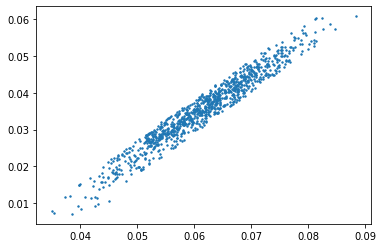

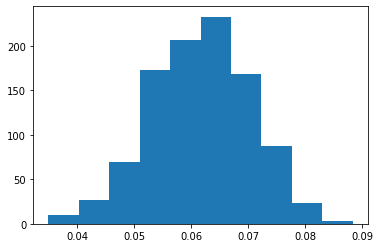

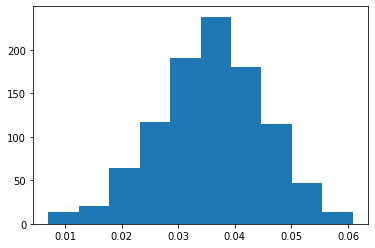

In [77]:
eps = 2.5
b = result.samples['beta'][np.where(result.discrepancies < eps)]
g = result.samples['gamma'][np.where(result.discrepancies < eps)]

plt.scatter(b, g, s = 2)
plt.show()

plt.hist(b)
plt.show()

plt.hist(g)
plt.show()

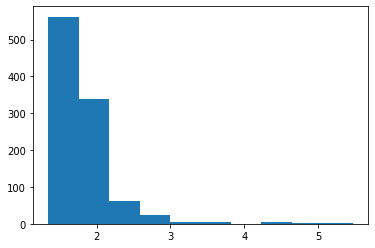

In [78]:
plt.hist(b/g)
plt.show()